In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import glob
import tqdm


In [ ]:
path_template = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/{exp_id}/{exp_id}/result/block/token_normalise_dwell_drach_npz"

df_dict = {}

for exp_id in ["ON0112", "ON0113", "ON0114", "ON0115"]:
    exp_path = path_template.format(exp_id = exp_id)
    print(exp_path)
    paths = np.random.choice(glob.glob(os.path.join(exp_path, "*.npz")), 100)
    kmer_list = []
    signal_list = []
    dwell_list = []
    
    for path in tqdm.tqdm(paths):
        data_dict = {}
        with np.load(path) as data:
            for key in data.keys():
                if "label_id" not in key:
                    data_dict[key] = data[key]
            segment_len_arr = np.cumsum(data_dict["segment_len_arr"], axis = 1) * 6 
            segment_slices = np.array([np.mean(data_dict["signal_token"][i,segment_len_arr[i,7]:segment_len_arr[i,8]])  for i in range(len(data_dict["signal_token"]))])
            kmer_token = data_dict["kmer_token"][:,8:13].view('S5').flatten().astype(str)
            dwell_token = np.array([len(data_dict["signal_token"][i,segment_len_arr[i,7]:segment_len_arr[i,8]])  for i in range(len(data_dict["signal_token"]))])
            kmer_list.append(kmer_token)
            signal_list.append(segment_slices)
            dwell_list.append(dwell_token)
    
    kmer_list = np.concatenate(kmer_list)
    signal_list = np.concatenate(signal_list)
    dwell_list = np.concatenate(dwell_list)
    
    df = pd.DataFrame({"signal_mean": signal_list, "kmer": kmer_list, "dwell": dwell_list})
    print(df)
    df_dict[exp_id] = df

In [ ]:
for exp_id in df_dict:
    df_dict[exp_id] = df_dict[exp_id].groupby("kmer")


19
AAACA: 0.000, 0.000, 0.000, 0.000
AAACC: 0.000, 0.000, 0.000, 0.000
AAACT: 0.000, 0.000, 0.000, 0.000
AGACA: 0.000, 0.000, 0.000, 0.000
AGACC: 0.000, 0.000, 0.000, 0.000
AGACT: 0.000, 0.000, 0.000, 0.000
CAACA: 0.845, 0.049, 0.000, 0.000
GAACA: 0.000, 0.000, 0.000, 0.000
GAACC: 0.000, 0.000, 0.000, 0.000
GAACT: 0.000, 0.000, 0.000, 0.000
GGACA: 0.000, 0.000, 0.000, 0.000
GGACC: 0.000, 0.000, 0.000, 0.000
GGACT: 0.000, 0.000, 0.000, 0.000
TAACA: 0.001, 0.000, 0.000, 0.000
TAACC: 0.000, 0.000, 0.000, 0.000
TAACT: 0.000, 0.001, 0.000, 0.000
TGACA: 0.000, 0.000, 0.000, 0.000
TGACC: 0.000, 0.000, 0.000, 0.000
TGACT: 0.000, 0.000, 0.000, 0.000


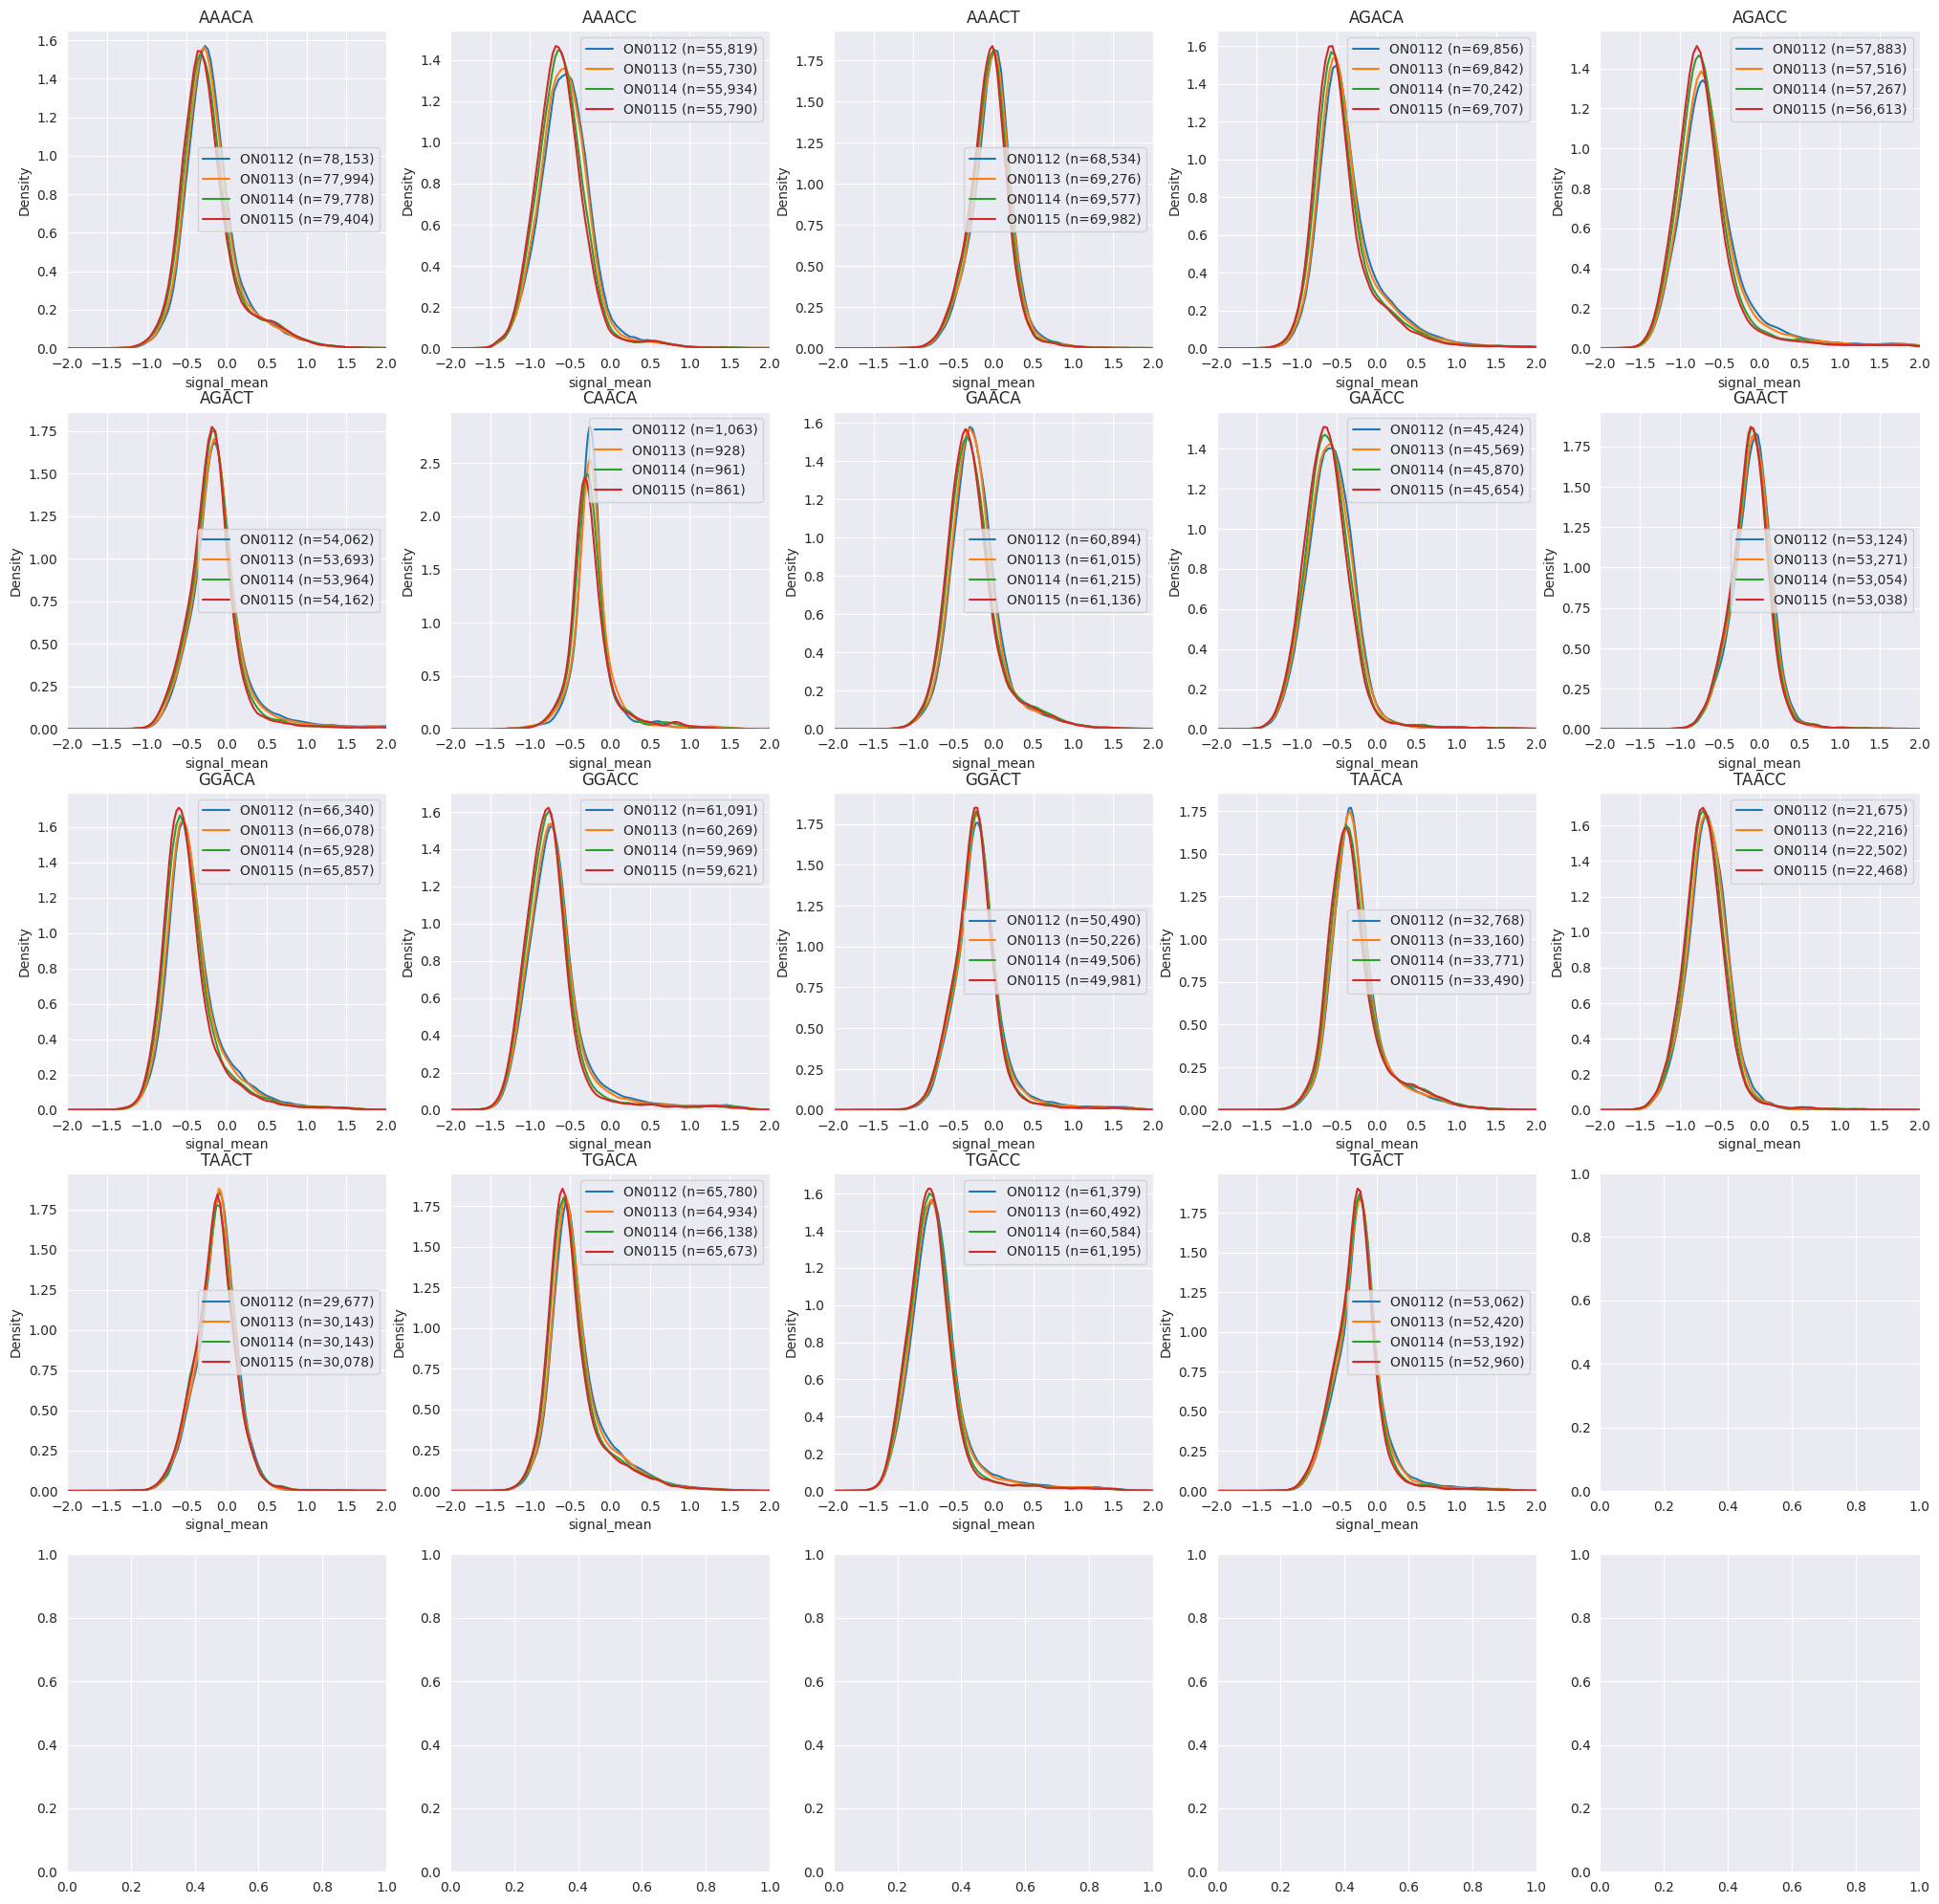

In [92]:
import warnings
warnings.filterwarnings(action='ignore')
from scipy.stats import kstest, ranksums, mannwhitneyu

fig, axes = plt.subplots(5, 5, figsize = (25,25))

motif_list = [x for x in df_dict["ON0112"].groups.keys() if len(df_dict["ON0112"].get_group(x)) > 1000]
print(len(motif_list))

for i, motif in enumerate(motif_list):
    ax = axes[i//5, i%5]
    for exp_id in df_dict:
        df = df_dict[exp_id].get_group(motif)
        sns.kdeplot(df["signal_mean"], ax = ax, label = f"{exp_id} (n={len(df):,})")
        ax.legend()
        ax.set_xlim(-2,2)
    ax.set_title(motif)
    
    ## Rep1 vs Rep2, May
    _, p1 = mannwhitneyu(df_dict["ON0112"].get_group(motif)["signal_mean"], df_dict["ON0113"].get_group(motif)["signal_mean"], method = "asymptotic")
    
    ## Rep1 vs Rep2, August
    _, p2 = mannwhitneyu(df_dict["ON0114"].get_group(motif)["signal_mean"], df_dict["ON0115"].get_group(motif)["signal_mean"], method = "asymptotic")
    
    ## May vs. August, Rep1
    _, p3 = mannwhitneyu(df_dict["ON0112"].get_group(motif)["signal_mean"], df_dict["ON0114"].get_group(motif)["signal_mean"], method = "asymptotic")
    
    ## May vs. August, Rep2
    _, p4 = mannwhitneyu(df_dict["ON0113"].get_group(motif)["signal_mean"], df_dict["ON0115"].get_group(motif)["signal_mean"], method = "asymptotic")
    
    print(f"{motif}: {p1:.3f}, {p2:.3f}, {p3:.3f}, {p4:.3f}")

plt.show()


19


19it [00:19,  1.03s/it]


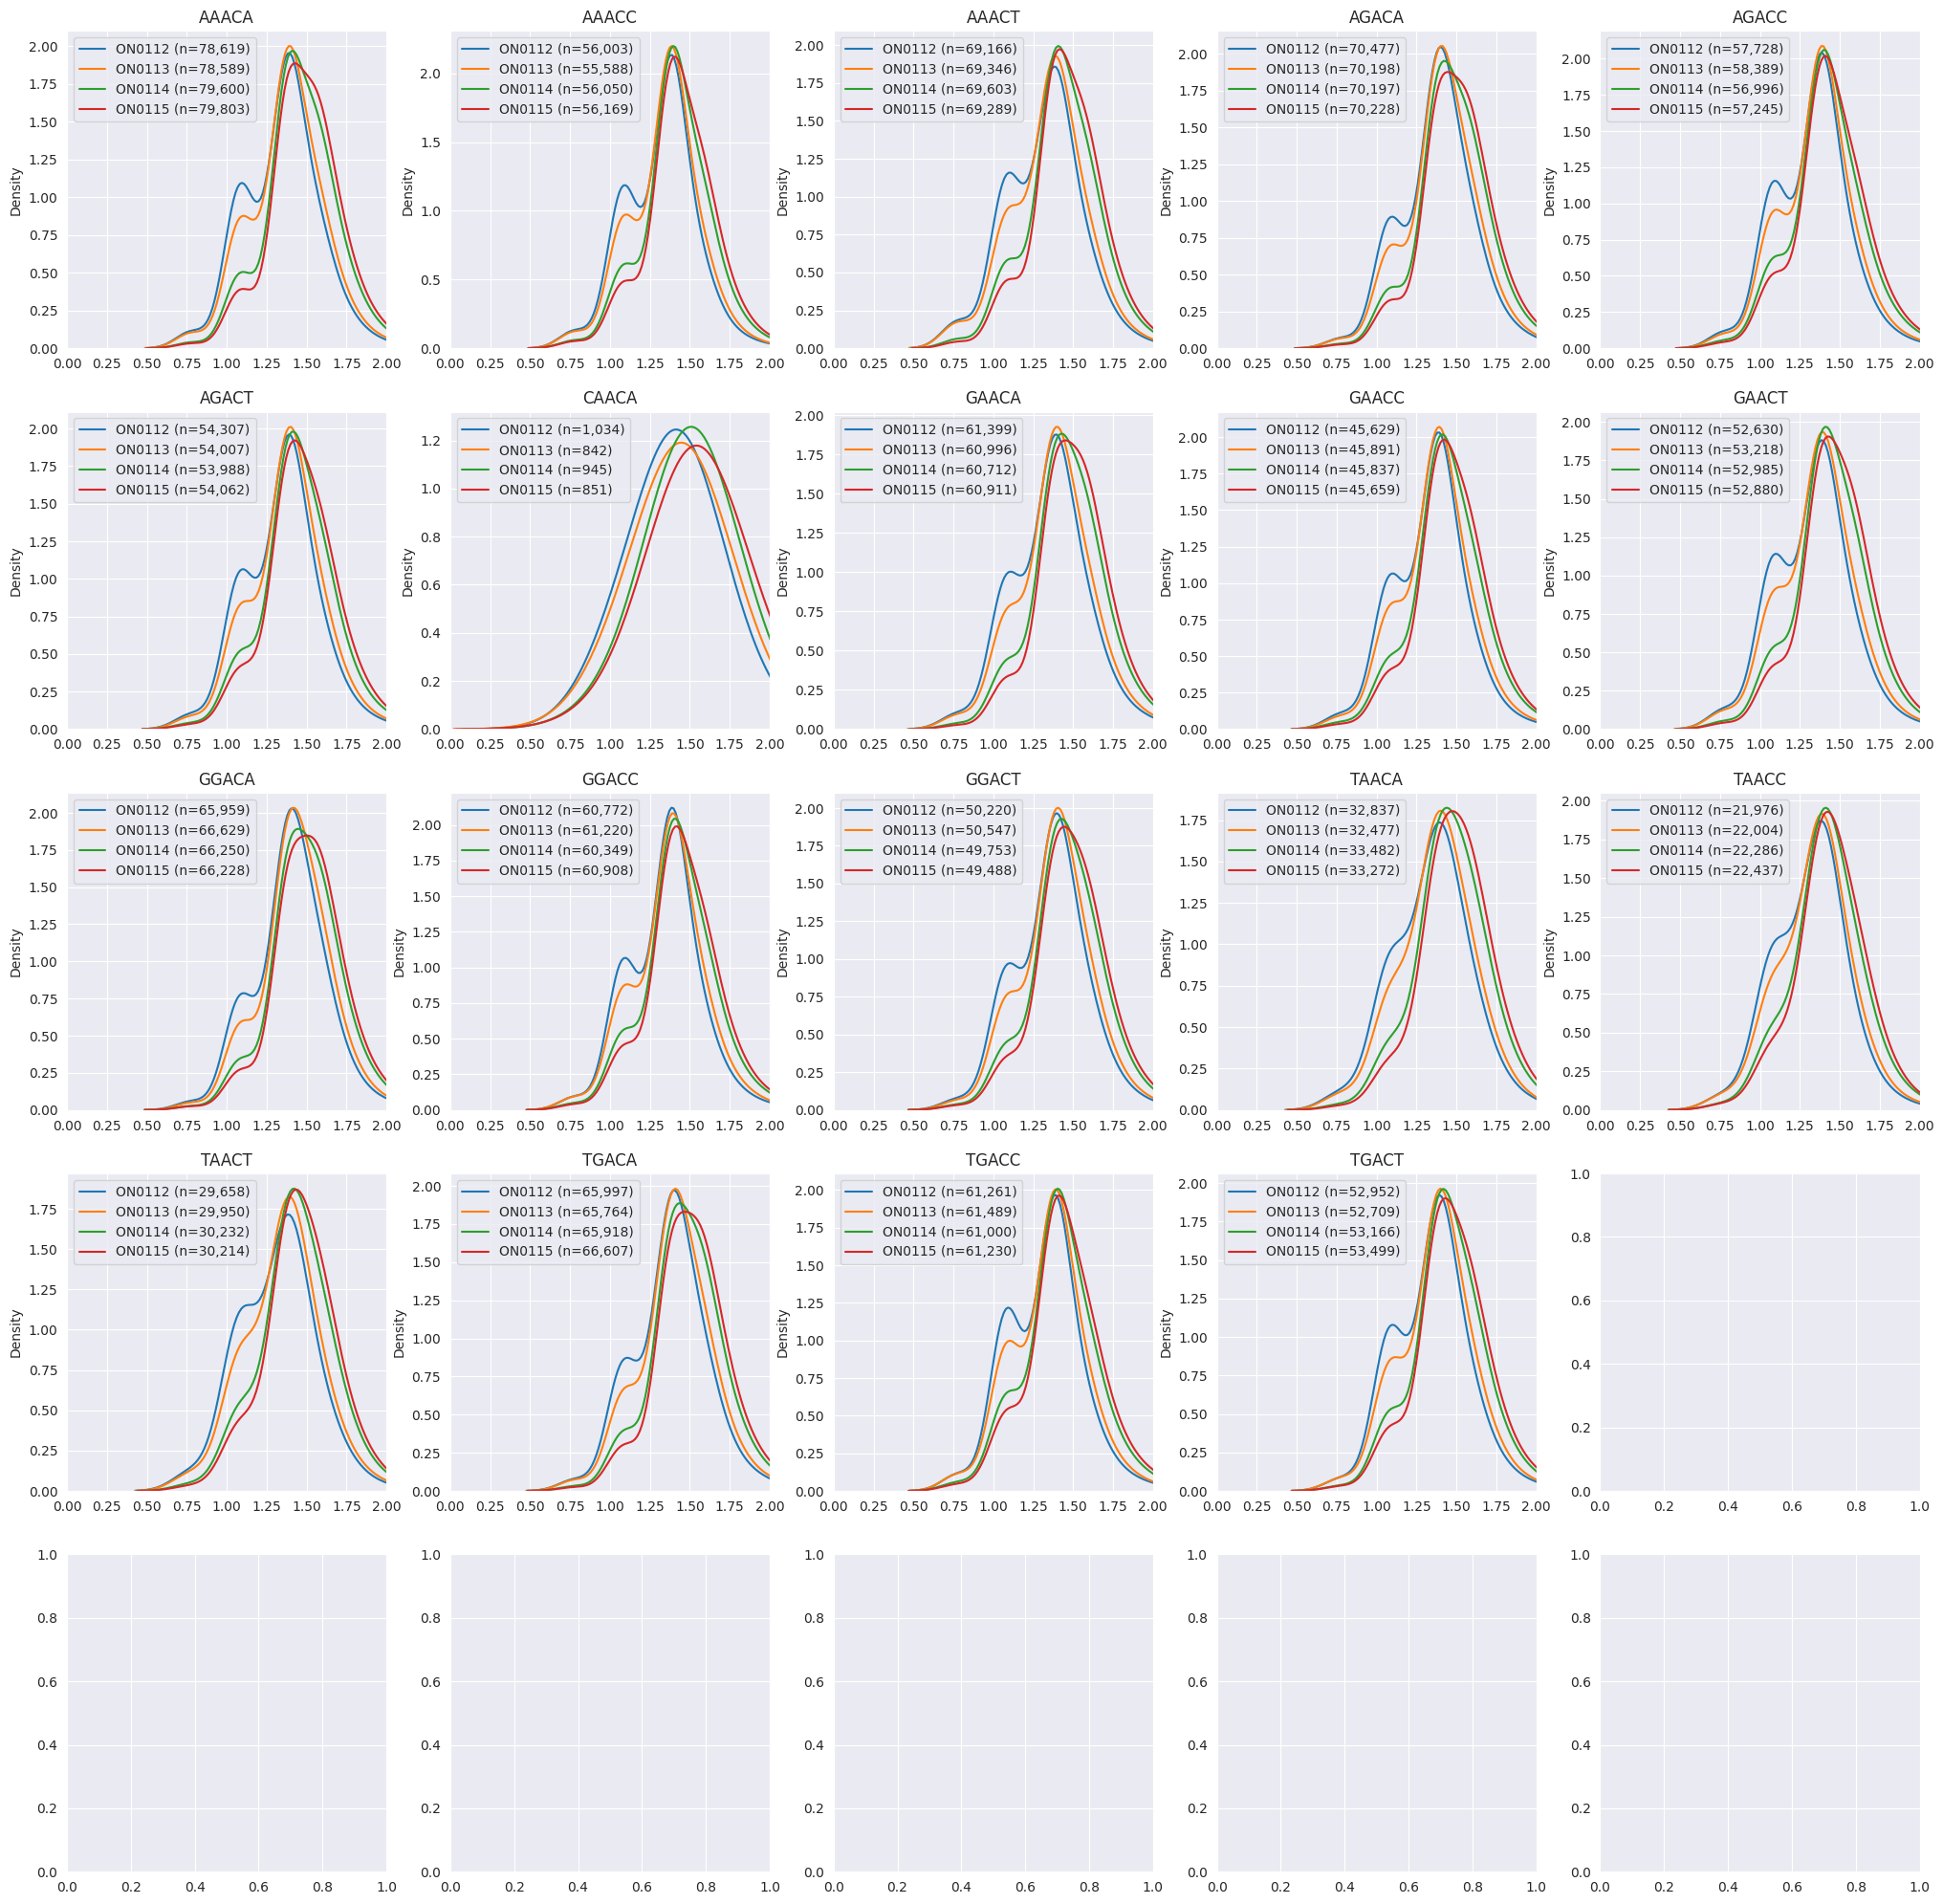

In [102]:
import warnings
warnings.filterwarnings(action='ignore')
from scipy.stats import kstest, ranksums, mannwhitneyu

fig, axes = plt.subplots(5, 5, figsize = (25,25))

motif_list = [x for x in df_dict["ON0112"].groups.keys() if len(df_dict["ON0112"].get_group(x)) > 1000]
print(len(motif_list))
for i, motif in tqdm.tqdm(enumerate(motif_list)):
    ax = axes[i//5, i%5]
    for exp_id in df_dict:
        df = df_dict[exp_id].get_group(motif)
        sns.kdeplot(np.log10(df["dwell"].values), ax = ax, label = f"{exp_id} (n={len(df):,})",
                    bw_adjust = 4)
        ax.legend()
        ax.set_xlim(0,2)
    ax.set_title(motif)

plt.show()
